# Navigation Task (NAV)

The navigation benchmark models a simplified robot navigating to a goal while avoiding an obstacle.

In [5]:
import argparse
import jax
import jax.numpy as jnp
import immrax as irx
from time import time
from functools import partial

parser = argparse.ArgumentParser()
parser.add_argument('--plot', action='store_true', help='save reach-set plot (nav.png/.pdf)')
args, _ = parser.parse_known_args()

device = 'cpu'

## The System Dynamics

The state $x = (p_x, p_y, \theta, v)^T$ consists of the horizontal and vertical positions $(p_x, p_y)$, velocity $v$, and the angle $\theta$ of the robot. The inputs are $u = (u_1, u_2)^T$ which control the acceleration and the heading rate.

The system dynamics are given by:
$$
\begin{aligned}
\dot{p}_x &= v \cos(\theta) \\
\dot{p}_y &= v \sin(\theta) \\
\dot{v} &= u_1 \\
\dot{\theta} &= u_2
\end{aligned}
$$

In [6]:
class NAV (irx.System):
    def __init__(self) -> None:
        self.evolution = 'continuous'
        self.xlen = 4 

    def f(self, t: jnp.ndarray, x: jnp.ndarray, u: jnp.ndarray, w: jnp.ndarray) -> jnp.ndarray:
        px, py, v, th = x
        u1, u2 = jnp.tanh(u)
        return jnp.array([
            v*jnp.cos(th),
            v*jnp.sin(th),
            u1,
            u2
        ])

olsys = NAV()
net = irx.NeuralNetwork('nn-nav-set')
# net = irx.NeuralNetwork('nn-nav-point')
clsys = irx.NNCSystem(olsys, net)

Successfully loaded model from nn-nav-set/model.eqx


## Initial Conditions and Specifications

**Controller:** A neural network controller (`nn-nav-set`) is used to guide the robot.

**Initial Set:**
$$
\begin{aligned}
p_x &\in [2.9, 3.1] \\
p_y &\in [2.9, 3.1] \\
v &= 0 \\
\theta &= 0
\end{aligned}
$$

**Specifications:**
-   **Goal:** Reach the box centered at origin $[0,0]$ with size $1\times 1$ ($p_x, p_y \in [-0.5, 0.5]$).
-   **Obstacle:** Avoid the region $p_x \in [1, 2], p_y \in [1, 2]$.

In [7]:
perm = irx.standard_permutation(1+4+2+1)[0]
cent = jnp.array([3., 3., 0., 0.])
pert = jnp.array([0.1, 0.1, 0., 0.])
ix0 = irx.icentpert(cent, pert)
pt0 = irx.Polytope.from_interval(ix0)

t0 = 0.
tf = 6.
dt = 0.01
max_steps = round((tf-t0)/dt)
solver = 'tsit5'

goal = irx.icentpert(jnp.zeros(4), [0.5,0.5,jnp.inf,jnp.inf])
obs = irx.interval([1., 1.,-jnp.inf,-jnp.inf], [2., 2., jnp.inf, jnp.inf])

print(goal, obs)

[⟦-0.5, 0.5⟧ ⟦-0.5, 0.5⟧ ⟦-inf, inf⟧ ⟦-inf, inf⟧] [⟦1., 2.⟧ ⟦1., 2.⟧ ⟦-inf, inf⟧ ⟦-inf, inf⟧]


## Reachability Analysis

We compute the reachable set using `immrax`'s `FastlinAdjointEmbedding`. We use a partition of the initial set to improve accuracy.

In [8]:
w_map = lambda t, x : irx.izeros(1)

def reach_set(t0, dt, tf, ipx0, kap) :
    ix0 = irx.iconcatenate((irx.ut2i(ipx0), irx.izeros(2)))
    # ix0 = ipx0
    pt0 = irx.Polytope.from_interval(ix0)
    Hp0 = jnp.eye(4)
    N0 = jnp.zeros((0,4))
    fae = irx.FastlinAdjointEmbedding(clsys, Hp0, N0, perm, kap=kap, forward_mode="ibp", iterated=True)
    RS = fae.compute_reachset(t0, tf, pt0, (w_map,), dt, solver=solver)

    def check_goal (oxi, alphai, yi, alphapi) :
        ix = irx.interval(alphapi) @ irx.interval(-yi[:4], yi[:4]) + oxi
        return irx.utils.check_containment(ix, goal)

    def check_obs (oxi, alphai, yi, alphapi) :
        ix = irx.interval(alphapi) @ irx.interval(-yi[:4], yi[:4]) + oxi
        return irx.utils.check_containment(ix, obs)

    yy = RS.ys[0]
    aux = RS.ys[1]
    last = max_steps
    n = max_steps + 1
    G = check_goal(yy.ox[last], yy.alpha[last], yy.y[last], aux[0][last])
    O = jax.vmap(check_obs, in_axes=(0, 0, 0, 0))(
        yy.ox[:n], yy.alpha[:n], yy.y[:n], aux[0][:n]
    )

    return RS, G, jnp.any(O == 1).astype(int) + 2*jnp.any(O == 0).astype(int)

# partitions = irx.utils.get_partitions_ut(irx.i2ut(irx.icentpert(cent[:2], pert[:2])), 15**2)
partitions = irx.utils.get_partitions_ut(irx.i2ut(irx.icentpert(cent[:2], pert[:2])), 14**2)

@partial(jax.jit, backend=device)
def get_reach_set (t0, dt, tf, partitions, kap) :
    return jax.vmap(reach_set, in_axes=(None, None, None, 0, None))(t0, dt, tf, partitions, kap)

# JIT Compile
jit_t0 = time()
_ = jax.block_until_ready(get_reach_set(0., dt, dt, partitions, 0.1))
jit_tf = time()
print(f'JIT compiled in {jit_tf - jit_t0:.5f} seconds')

/tmp/claude-1000/ipykernel_1746376/1139999924.py:9: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  fae = irx.FastlinAdjointEmbedding(clsys, Hp0, N0, perm, kap=kap, forward_mode="ibp", iterated=True)


JIT compiled in 13.73375 seconds


In [9]:
# ix0 = irx.icentpert(cent, 0.125*pert)
# ix0 = irx.icentpert(cent, pert*jnp.array([0.05, 0.05, 0.1, 0.1]))
# pt0 = irx.Polytope.from_interval(ix0)
# dt = 0.01

N = 1
(RS, G, O), times = irx.utils.run_times(N, get_reach_set, t0, dt, tf, partitions, 5.)
print(f'Computed Reachable Set in {jnp.mean(times):.5f} ± {jnp.std(times):.5f} over {N} runs')

runtime = jnp.mean(times)

if jnp.all(G == 1) :
    if jnp.all(O == 0) :
        status = 'VERIFIED'
    elif jnp.all(O == 1) :
        status = 'VIOLATED'
    else :
        status = 'UNKNOWN'
elif jnp.all(G == -1) :
    status = 'VIOLATED'
else :
    status = 'UNKNOWN'

print(f'NAV,robust,{status},{runtime},comment')

Computed Reachable Set in 33.00439 ± 0.00000 over 1 runs
NAV,robust,VERIFIED,33.00439453125,comment


6 Plotting error on i=50
[[ 1.0008974e+00  3.0777575e-03  4.8633614e-01  3.5171282e-02]
 [-2.2242793e-03  9.9234629e-01  1.0528859e-01 -1.1021467e-01]
 [-7.8587718e-06 -1.0060137e-05  9.9997592e-01 -1.1706242e-05]
 [ 4.9772218e-02  1.6839842e-01  2.5864300e-01  8.4236938e-01]]
6 Plotting error on i=100
[[ 0.9905156   0.05892442  0.99937505  0.10681376]
 [-0.04826819  0.83595514  0.06085074 -0.28542173]
 [-0.02224561 -0.01623305  0.96222126 -0.00877743]
 [ 0.11277007  0.5451217   0.87678695  0.33535278]]
6 Plotting error on i=150
[[ 0.7584426   0.11364567  1.192536    0.09912843]
 [ 0.03906084  0.48918128 -0.07350598 -0.37034884]
 [-0.14466149 -0.06078568  0.67208767  0.00495412]
 [-0.3651865   0.52286416 -0.05433965  0.02522026]]
6 Plotting error on i=200
[[ 0.05787278  0.16032417  0.56728786  0.03953641]
 [ 0.18804084  0.07027756  0.07785555 -0.25597015]
 [-0.25118268 -0.07023822  0.10505833  0.03596361]
 [-0.19755164  0.3098422  -0.24319312 -0.05960248]]
6 Plotting error on i=250
[[-

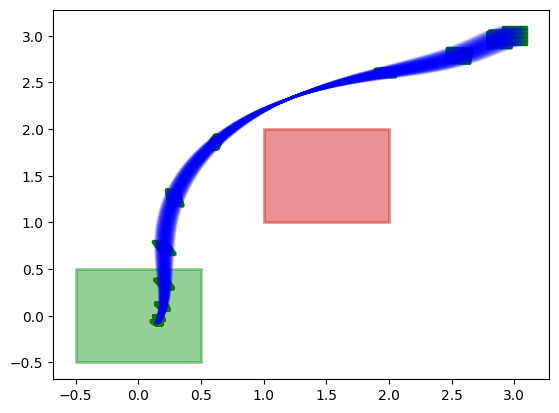

In [10]:
if args.plot:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    from pypoman import plot_polygon
    import numpy as onp

    yy = RS.ys[0]
    aux = RS.ys[1]

    fig, ax = plt.subplots()

    PLOT_EVERY = 50

    # Goal and Obstacle
    irx.utils.draw_iarray(ax, irx.interval([1., 1.], [2., 2.]), ec='tab:red', fc='tab:red', alpha=0.5)
    irx.utils.draw_iarray(ax, irx.icentpert([0., 0.], [.5, .5]), ec='tab:green', fc='tab:green', alpha=0.5)

    errors = []

    for p in range(len(partitions)) :
        ax.plot(yy.ox[p,:,0], yy.ox[p,:,1], c='blue', alpha=0.1)

        mins = []
        maxs = []

        for i in range(0,max_steps,PLOT_EVERY) :
            pti = pt0.__class__.from_parametope(irx.hParametope(yy.ox[p,i,:], yy.alpha[p,i,:], yy.y[p,i,:]))
            try :
                pti.plot_projection(ax)
            except Exception as e :
                print(f'{p} Plotting error on {i=}')
                print(aux[0][p,i,:])
                errors.append(p)

    fig.savefig('nav.png', dpi=300)
    fig.savefig('nav.pdf')
    print('Saved nav.{png,pdf}')